In [1]:
# ============================================================
# Imports & Configuration
# ============================================================

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.operators import MeasurementOperator
from src.admm import admm_solve
from src.svt import svt, effective_rank
from src.metrics import relative_error, psnr, ssim
from config import RHO, MAX_ITER, TOL

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

# 1. Build a toy problem with known ground truth

In [2]:
rng = np.random.default_rng(42)
n = 20
rank = 2
m = 3 * rank * n      # well above the recovery threshold

#Build exact rank-2 matrix
U = rng.standard_normal((n, rank))
V = rng.standard_normal((n, rank))
X_true = U @ V.T

print(f"X_true shape : {X_true.shape}")
print(f"X_true rank  : {np.linalg.matrix_rank(X_true)}")
print(f"Measurements : {m}  out of  {n*n}  possible  ({100*m/(n*n):.1f}%)")
print(f"Degrees of freedom of rank-{rank} matrix: {rank*(2*n - rank)}")
print(f"Oversampling factor: {m / (rank*(2*n - rank)):.2f}x")

X_true shape : (20, 20)
X_true rank  : 2
Measurements : 120  out of  400  possible  (30.0%)
Degrees of freedom of rank-2 matrix: 76
Oversampling factor: 1.58x


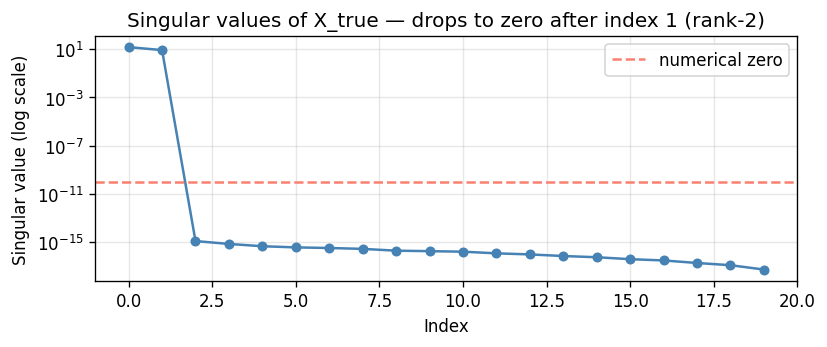

In [3]:
#Singular values of X_true, confirm exactly rank-2
sigma_true = np.linalg.svd(X_true, compute_uv=False)

plt.figure(figsize=(7, 3))
plt.semilogy(sigma_true, 'o-', color='steelblue', markersize=5)
plt.axhline(y=1e-10, color='salmon', linestyle='--', label='numerical zero')
plt.title("Singular values of X_true — drops to zero after index 1 (rank-2)")
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-1, n)
plt.tight_layout()
plt.show()

# 2. Run the solver

In [4]:
op = MeasurementOperator(n=n, m=m, seed=42)
y = op.measure(X_true)

result = admm_solve(op, y, rho=RHO, max_iter=MAX_ITER, tol=TOL,
                    X_true=X_true, verbose=True)

print(f"\nConverged : {result.converged}")
print(f"Iterations: {result.n_iters}")

  Iter        Primal          Dual    Rank      RelErr
-------------------------------------------------------
     1      9.406201     14.109302       0    1.000000
     2      7.081686      2.096644      18    0.903185
     3      0.357803      1.440769      14    0.776939
     4      0.252229      1.215299      14    0.752614
     5      0.192882      1.060247      13    0.730824
    51      0.012001      0.121923       8    0.324670
   101      0.004506      0.030722       7    0.211329
   151      0.000916      0.006040       6    0.184209
   201      0.000176      0.001147       6    0.178833
   251      0.000033      0.000216       6    0.177811
   301      0.000006      0.000041       6    0.177618

Converged at iteration 344
Primal residual: 1.49e-06
Dual residual: 9.68e-06
Final rank: 6
Relative error: 0.177584

Converged : True
Iterations: 344


# 3. Convergence diagnostics

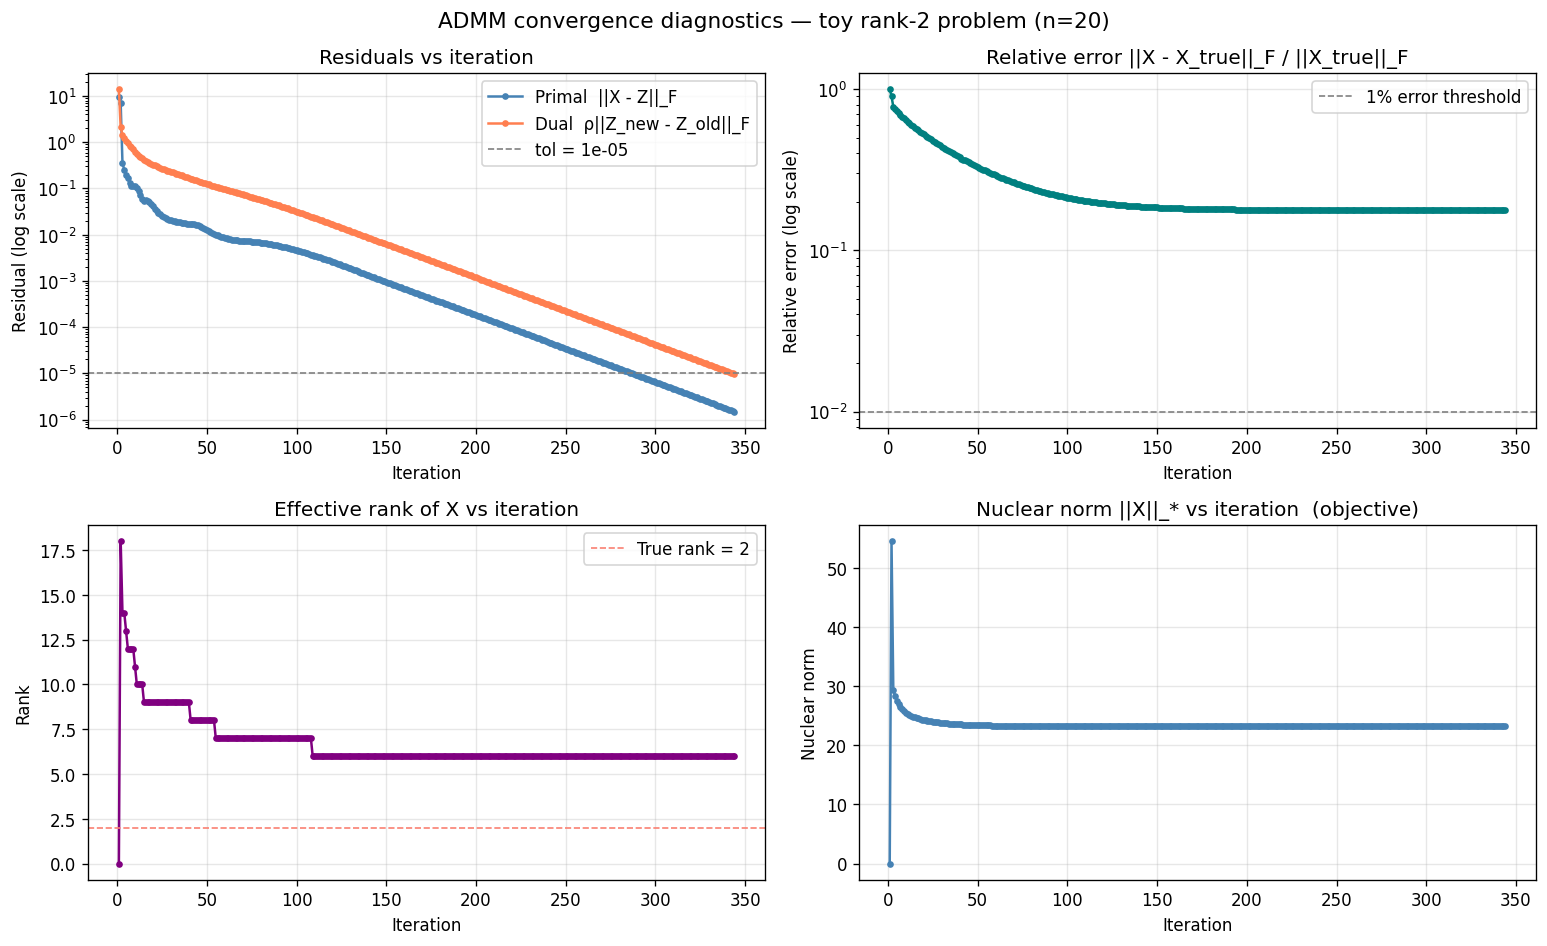

In [5]:
h = result.history
iters = range(1, result.n_iters + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Primal and dual residuals
axes[0, 0].semilogy(iters, h.primal_residuals, color='steelblue',
                    linewidth=1.5, label='Primal  ||X - Z||_F', marker='.')
axes[0, 0].semilogy(iters, h.dual_residuals, color='coral',
                    linewidth=1.5, label='Dual  ρ||Z_new - Z_old||_F', marker='.')
axes[0, 0].axhline(y=TOL, color='gray', linestyle='--', linewidth=1,
                   label=f'tol = {TOL}')
axes[0, 0].set_title("Residuals vs iteration")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Residual (log scale)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Relative error vs X_true
axes[0, 1].semilogy(iters, h.rel_errors, color='teal', linewidth=1.5, marker='.')
axes[0, 1].axhline(y=1e-2, color='gray', linestyle='--', linewidth=1,
                   label='1% error threshold')
axes[0, 1].set_title("Relative error ||X - X_true||_F / ||X_true||_F")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Relative error (log scale)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Rank evolution
axes[1, 0].plot(iters, h.ranks, color='purple', linewidth=1.5, marker='.')
axes[1, 0].axhline(y=rank, color='salmon', linestyle='--', linewidth=1,
                   label=f'True rank = {rank}')
axes[1, 0].set_title("Effective rank of X vs iteration")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Rank")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Nuclear norm (objective value)
axes[1, 1].plot(iters, h.objective_values, color='steelblue', linewidth=1.5, marker='.')
axes[1, 1].set_title("Nuclear norm ||X||_* vs iteration  (objective)")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Nuclear norm")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("ADMM convergence diagnostics — toy rank-2 problem (n=20)", fontsize=13)
plt.tight_layout()
plt.show()

# 4. Visual recovery check

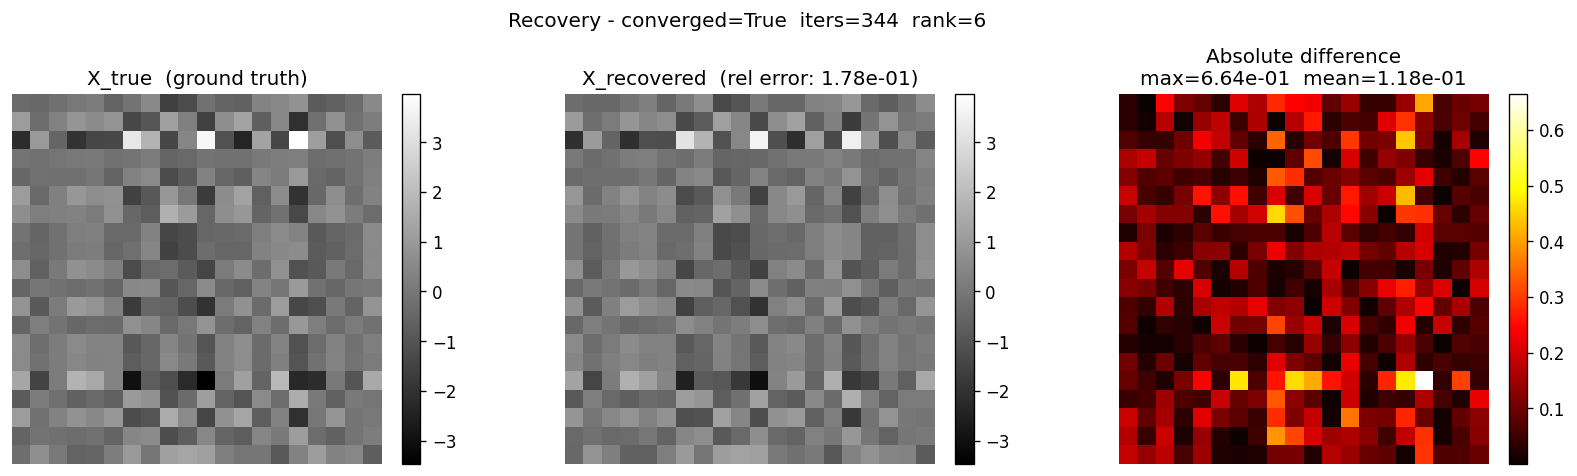

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vmin = min(X_true.min(), result.X.min())
vmax = max(X_true.max(), result.X.max())

im0 = axes[0].imshow(X_true, vmin=vmin, vmax=vmax)
axes[0].set_title("X_true  (ground truth)")
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(result.X, vmin=vmin, vmax=vmax)
rel_err = np.linalg.norm(result.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
axes[1].set_title(f"X_recovered  (rel error: {rel_err:.2e})")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

diff = np.abs(result.X - X_true)
im2 = axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f"Absolute difference\nmax={diff.max():.2e}  mean={diff.mean():.2e}")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"Recovery - converged={result.converged}  "
             f"iters={result.n_iters}  rank={effective_rank(result.X)}", fontsize=12)
plt.tight_layout()
plt.show()

# 5. Singular value recovery check
Confirm the solver recovers the correct singular values, not just the Frobenius-norm error.

True singular values     : [14.978383  8.488254  0.        0.        0.        0.      ]
Recovered singular values: [13.7725    7.287131  0.843971  0.698358  0.348903  0.283211]

Effective rank (tol=1e-6) : 6
Effective rank (tol=1e-3) : 6


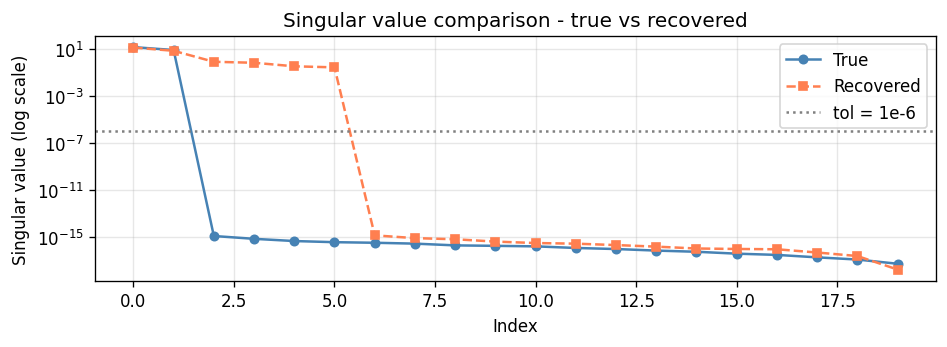

In [17]:
sigma_recovered = np.linalg.svd(result.X, compute_uv=False)

print("True singular values     :", np.round(sigma_true[:6], 6))
print("Recovered singular values:", np.round(sigma_recovered[:6], 6))
print(f"\nEffective rank (tol=1e-6) : {effective_rank(result.X, tol=1e-6)}")
print(f"Effective rank (tol=1e-3) : {effective_rank(result.X, tol=1e-3)}")

fig, ax = plt.subplots(figsize=(8, 3))
idx = np.arange(n)
ax.semilogy(idx, sigma_true, 'o-', color='steelblue', label='True', markersize=5)
ax.semilogy(idx, sigma_recovered, 's--', color='coral', label='Recovered', markersize=5)
ax.axhline(y=1e-6, color='gray', linestyle=':', label='tol = 1e-6')
ax.set_title("Singular value comparison - true vs recovered")
ax.set_xlabel("Index")
ax.set_ylabel("Singular value (log scale)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Sampling ratio sweep
How does recovery quality degrade as we reduce the number of measurements? 
The theoretical recovery threshold for a rank-r, n×n matrix is m ≈ r(2n − r) (degrees of freedom).

 Ratio      m   m/dof     rel_err   converged
--------------------------------------------------
  0.05     41    0.54    0.892234        True
  0.10     41    0.54    0.892234        True
  0.15     60    0.79    0.739895        True
  0.20     80    1.05    0.675958        True
  0.30    120    1.58    0.177584        True
  0.50    200    2.63    0.000001        True
  0.75    300    3.95    0.000001        True


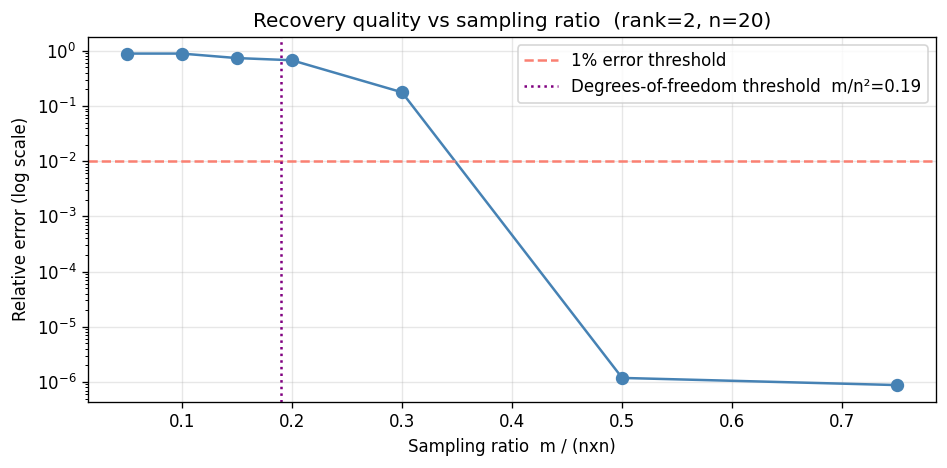

In [18]:
sampling_ratios = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75]
dof = rank * (2 * n - rank)   # degrees of freedom

sweep_results = []
print(f"{'Ratio':>6}  {'m':>5}  {'m/dof':>6}  {'rel_err':>10}  {'converged':>10}")
print("-" * 50)

for ratio in sampling_ratios:
    m_s = max(rank * n + 1, int(ratio * n * n))
    op_s = MeasurementOperator(n=n, m=m_s, seed=42)
    y_s  = op_s.measure(X_true)
    res  = admm_solve(op_s, y_s, verbose=False)
    err  = np.linalg.norm(res.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
    sweep_results.append((ratio, m_s, m_s/dof, err, res.converged))
    print(f"{ratio:>6.2f}  {m_s:>5d}  {m_s/dof:>6.2f}  {err:>10.6f}  {str(res.converged):>10}")

ratios_arr = [r[0] for r in sweep_results]
errors_arr = [r[3] for r in sweep_results]

plt.figure(figsize=(8, 4))
plt.semilogy(ratios_arr, errors_arr, 'o-', color='steelblue', linewidth=1.5, markersize=7)
plt.axhline(y=1e-2, color='salmon', linestyle='--', label='1% error threshold')
plt.axvline(x=dof / (n*n), color='purple', linestyle=':', linewidth=1.5,
            label=f'Degrees-of-freedom threshold  m/n²={dof/(n*n):.2f}')
plt.xlabel("Sampling ratio  m / (nxn)")
plt.ylabel("Relative error (log scale)")
plt.title(f"Recovery quality vs sampling ratio  (rank={rank}, n={n})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. $\rho$ (rho) sensitivity analysis
$\rho$ is the ADMM penalty parameter. It controls the trade-off between primal feasibility and 
dual convergence. Too small - slow primal convergence. Too large - slow dual convergence.

In [9]:
rho_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

rho_results = []
print(f"{'rho':>8}  {'iters':>7}  {'rel_err':>10}  {'converged':>10}")
print("-" * 45)

for rho_val in rho_values:
    res = admm_solve(op, y, rho=rho_val, max_iter=MAX_ITER, tol=TOL,
                     X_true=X_true, verbose=False)
    err = np.linalg.norm(res.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
    rho_results.append((rho_val, res.n_iters, err, res.converged, res.history))
    print(f"{rho_val:>8.3f}  {res.n_iters:>7d}  {err:>10.6f}  {str(res.converged):>10}")

     rho    iters     rel_err   converged
---------------------------------------------
   0.010     1000    0.179795       False
   0.100     1000    0.177573       False
   0.500      268    0.177572        True
   1.000      217    0.177583        True
   5.000     1000    0.177629       False
  10.000     1000    0.184608       False


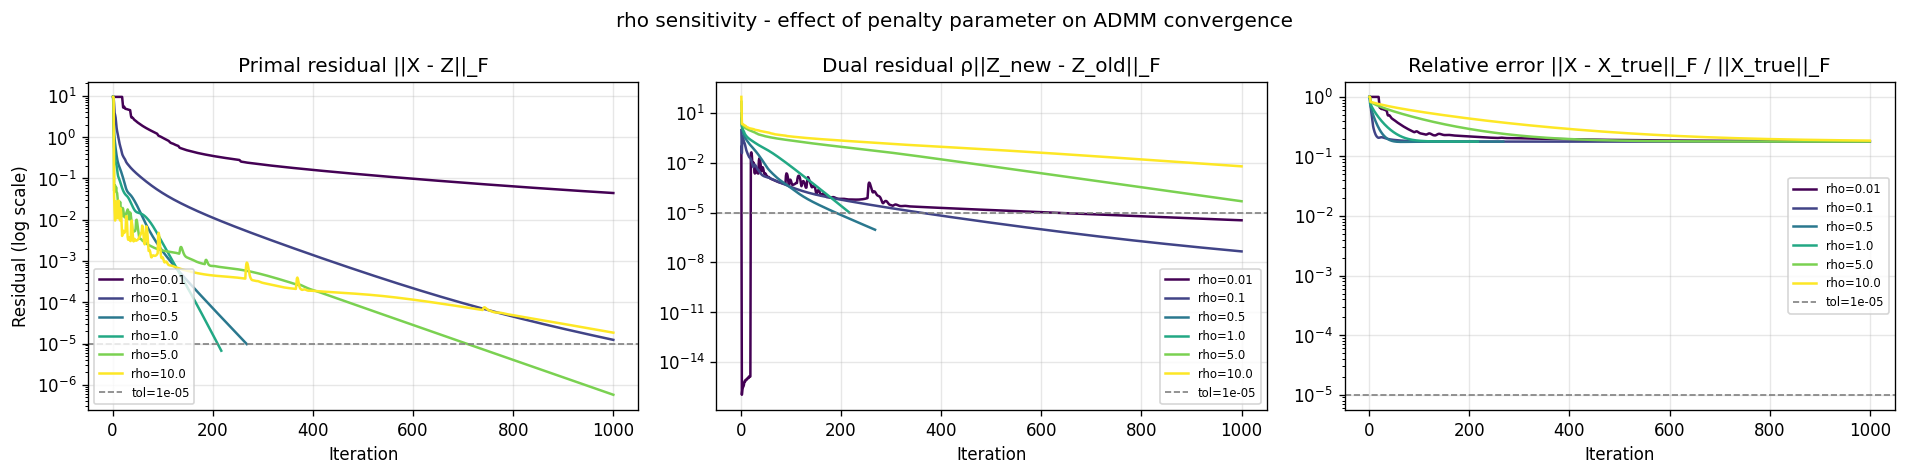

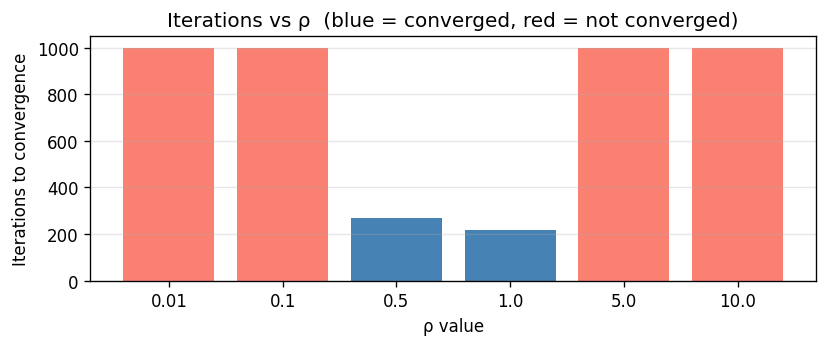

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = plt.cm.viridis(np.linspace(0, 1, len(rho_values)))

for i, (rho_val, n_iters, err, conv, hist) in enumerate(rho_results):
    iters_r = range(1, n_iters + 1)
    axes[0].semilogy(iters_r, hist.primal_residuals, color=colors[i],
                     linewidth=1.5, label=f'rho={rho_val}')
    axes[1].semilogy(iters_r, hist.dual_residuals, color=colors[i],
                     linewidth=1.5, label=f'rho={rho_val}')
    if hist.rel_errors:
        axes[2].semilogy(iters_r, hist.rel_errors, color=colors[i],
                         linewidth=1.5, label=f'rho={rho_val}')

for ax in axes:
    ax.axhline(y=TOL, color='gray', linestyle='--', linewidth=1, label=f'tol={TOL}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Iteration")

axes[0].set_title("Primal residual ||X - Z||_F")
axes[0].set_ylabel("Residual (log scale)")
axes[1].set_title("Dual residual rho ||Z_new - Z_old||_F")
axes[2].set_title("Relative error ||X - X_true||_F / ||X_true||_F")

plt.suptitle("rho sensitivity - effect of penalty parameter on ADMM convergence", fontsize=12)
plt.tight_layout()
plt.show()

#Summary bar chart: iterations to convergence
fig, ax = plt.subplots(figsize=(7, 3))
iters_list = [r[1] for r in rho_results]
bars = ax.bar([str(r[0]) for r in rho_results], iters_list,
              color=['steelblue' if r[3] else 'salmon' for r in rho_results])
ax.set_xlabel("ρ value")
ax.set_ylabel("Iterations to convergence")
ax.set_title("Iterations vs ρ  (blue = converged, red = not converged)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 8. Phase transition experiment
Vary both rank r and sampling ratio m/n² simultaneously. For each (r, m) pair, check 
whether the solver recovers X_true. This reproduces the phase diagram from Recht et al. (2010) 
and Candès & Recht (2008): white = perfect recovery, black = failure.

In [13]:
n_pt = 20       # matrix size for phase transition
n_trials = 3       # trials per cell (increase for smoother plot, costs time)
tol_recovery = 1e-2  # relative error threshold to declare success

ranks_pt   = [1, 2, 3, 4, 5]
ratios_pt  = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.75]

recovery_rate = np.zeros((len(ranks_pt), len(ratios_pt)))

print("Running phase transition experiment...")
for i, r in enumerate(ranks_pt):
    for j, ratio in enumerate(ratios_pt):
        m_pt = max(r * n_pt + 1, int(ratio * n_pt * n_pt))
        #Skip if underdetermined (m < dof)
        dof_pt = r * (2 * n_pt - r)
        successes = 0
        for trial in range(n_trials):
            rng_t = np.random.default_rng(trial * 100 + i * 10 + j)
            U_t = rng_t.standard_normal((n_pt, r))
            V_t = rng_t.standard_normal((n_pt, r))
            X_t = U_t @ V_t.T
            op_t = MeasurementOperator(n=n_pt, m=m_pt, seed=trial)
            y_t  = op_t.measure(X_t)
            res_t = admm_solve(op_t, y_t, verbose=False)
            err_t = np.linalg.norm(res_t.X - X_t, 'fro') / np.linalg.norm(X_t, 'fro')
            if err_t < tol_recovery:
                successes += 1
        recovery_rate[i, j] = successes / n_trials
    print(f"rank={r} done")



Running phase transition experiment...
rank=1 done
rank=2 done
rank=3 done
rank=4 done
rank=5 done


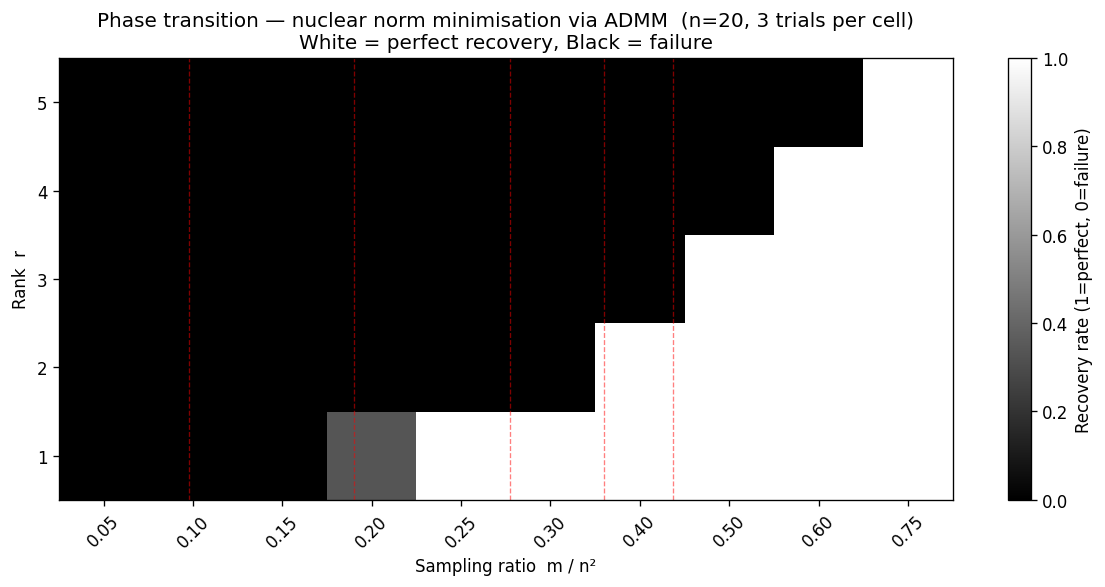

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(recovery_rate, aspect='auto', cmap='gray',
               vmin=0, vmax=1, origin='lower')
plt.colorbar(im, ax=ax, label='Recovery rate (1=perfect, 0=failure)')

ax.set_xticks(range(len(ratios_pt)))
ax.set_xticklabels([f'{r:.2f}' for r in ratios_pt], rotation=45)
ax.set_yticks(range(len(ranks_pt)))
ax.set_yticklabels([str(r) for r in ranks_pt])
ax.set_xlabel("Sampling ratio  m / n²")
ax.set_ylabel("Rank  r")
ax.set_title(f"Phase transition - nuclear norm minimisation via ADMM  (n={n_pt}, {n_trials} trials per cell)\n"
             "White = perfect recovery, Black = failure")

# Overlay the theoretical degrees-of-freedom threshold
for i, r in enumerate(ranks_pt):
    dof_r = r * (2 * n_pt - r)
    threshold_ratio = dof_r / (n_pt * n_pt)
    ax.axvline(x=np.interp(threshold_ratio, ratios_pt,
                           range(len(ratios_pt))),
               color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

# 9. Operator verification tests
Verify that the measurement operator and z_update are working correctly.

In [15]:
# Test z_update: A(Z) = y must hold exactly after z_update
X_test = np.zeros((n, n))
Lam_test = np.zeros((n, n))
Z_test = op.z_update(X_test, Lam_test, y, rho=1.0)

constraint_residual = np.linalg.norm(op.forward(Z_test) - y)
print(f"z_update constraint residual ||A(Z) - y|| : {constraint_residual:.2e}")
print(f"  (should be ~1e-10 if z_update is correct)")

# Test SVT: singular values should be thresholded by 1/rho
from src.svt import svt
Z_test2 = op.adjoint(y)
Lam_test2 = np.zeros((n, n))
rho_test = 1
X_test2 = svt(Z_test2 - Lam_test2 / rho_test, 1.0 / rho_test)

sigma_in  = np.linalg.svd(Z_test2, compute_uv=False)
sigma_out = np.linalg.svd(X_test2, compute_uv=False)

print(f"\nSVT verification (threshold = {1/rho_test:.2f}):")
print(f"  Input  singular values (top 5): {np.round(sigma_in[:5], 4)}")
print(f"  Output singular values (top 5): {np.round(sigma_out[:5], 4)}")
print(f"  Reduction (= threshold for large values): {np.round(sigma_in[:5] - sigma_out[:5], 4)}")

z_update constraint residual ||A(Z) - y|| : 1.28e-14
  (should be ~1e-10 if z_update is correct)

SVT verification (threshold = 1.00):
  Input  singular values (top 5): [17.8489 12.9449 11.0344 10.0685  9.7564]
  Output singular values (top 5): [16.8489 11.9449 10.0344  9.0685  8.7564]
  Reduction (= threshold for large values): [1. 1. 1. 1. 1.]
